### Bibliotecas utilizadas para análise

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


### 1 - Compreensão da Estrutura do Dataset

In [11]:
df = pd.read_csv("../data/Breast_Cancer.csv")

df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [4]:
df.shape

(4024, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

### 2 - Estatísticas Descritivas

In [6]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


### 4 - Identificação de Outliers e comportamento dos dados nos graficos em questão

In [7]:
atributes = [
    "Age",
    "Tumor Size",
    "Regional Node Examined",
    "Reginol Node Positive",
    "Survival Months"
]

for coluna in atributes:

    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    baixos = df[df[coluna] < lower]
    altos = df[df[coluna] > upper]

    total = len(baixos) + len(altos)

    print(f"\n--- {coluna} ---")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {lower}")
    print(f"Limite superior: {upper}")
    print(f"Outliers baixos: {len(baixos)}")
    print(f"Outliers altos: {len(altos)}")
    print(f"Total de outliers: {total}")


--- Age ---
Q1: 47.0
Q3: 61.0
IQR: 14.0
Limite inferior: 26.0
Limite superior: 82.0
Outliers baixos: 0
Outliers altos: 0
Total de outliers: 0

--- Tumor Size ---
Q1: 16.0
Q3: 38.0
IQR: 22.0
Limite inferior: -17.0
Limite superior: 71.0
Outliers baixos: 0
Outliers altos: 222
Total de outliers: 222

--- Regional Node Examined ---
Q1: 9.0
Q3: 19.0
IQR: 10.0
Limite inferior: -6.0
Limite superior: 34.0
Outliers baixos: 0
Outliers altos: 72
Total de outliers: 72

--- Reginol Node Positive ---
Q1: 1.0
Q3: 5.0
IQR: 4.0
Limite inferior: -5.0
Limite superior: 11.0
Outliers baixos: 0
Outliers altos: 344
Total de outliers: 344

--- Survival Months ---
Q1: 56.0
Q3: 90.0
IQR: 34.0
Limite inferior: 5.0
Limite superior: 141.0
Outliers baixos: 18
Outliers altos: 0
Total de outliers: 18


Age

A variável Age não apresentou outliers, considerando o intervalo definido pelo método do IQR, com limite inferior de 26 anos e limite superior de 82 anos. Isso indica que as idades dos pacientes estão distribuídas de forma estável dentro da faixa esperada, sem valores extremos que possam comprometer a análise. Esse comportamento sugere boa consistência dos dados relacionados à idade e uma distribuição homogênea entre os registros.

Tumor Size

A variável Tumor Size apresentou 222 outliers altos, com valores acima do limite superior de 71. Esses casos representam pacientes com tumores significativamente maiores em relação à maior parte da amostra. A presença desses valores extremos pode estar associada a casos clínicos mais severos, possivelmente relacionados a estágios avançados da doença ou tumores com maior agressividade. Por esse motivo, esses outliers possuem relevância analítica e clínica, sendo importantes para compreender diferentes perfis de gravidade entre os pacientes.

Regional Node Examined

Na variável Regional Node Examined, foram identificados 72 outliers altos, correspondentes a valores superiores a 34 linfonodos examinados. Esse comportamento indica a existência de pacientes submetidos a avaliações nodais mais extensas, o que pode refletir procedimentos clínicos mais detalhados, cirurgias mais abrangentes ou casos considerados de maior complexidade. Esses valores extremos são relevantes para a análise, pois podem representar diferentes níveis de investigação clínica.

Reginol Node Positive

A variável Reginol Node Positive apresentou 344 outliers altos, com valores acima de 11 linfonodos positivos. Esse resultado é extremamente relevante do ponto de vista clínico, pois sugere pacientes com maior comprometimento nodal, o que pode estar diretamente relacionado à progressão da doença e a um pior prognóstico. A quantidade significativa de outliers nessa variável reforça a existência de casos com maior gravidade clínica no dataset.

Survival Months

A variável Survival Months apresentou 18 outliers baixos, com valores inferiores a 5 meses de sobrevivência. Esses registros representam pacientes com tempo de sobrevida significativamente menor em comparação ao restante da amostra, podendo indicar evolução clínica rápida, estágios avançados da doença ou menor resposta ao tratamento. A identificação desses valores extremos é importante para a compreensão dos diferentes perfis prognósticos presentes no conjunto de dados.

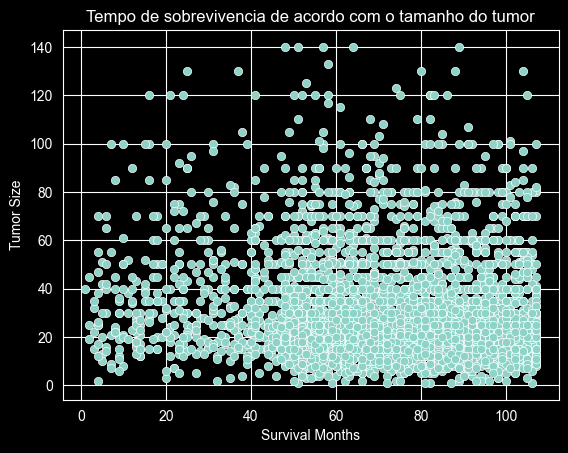

In [16]:
sns.scatterplot(
    x=df['Survival Months'],
    y=df['Tumor Size'],
)

plt.title("Tempo de sobrevivencia de acordo com o tamanho do tumor")
plt.savefig("../charts_images/tumorSizeSurvival.png", dpi=300, bbox_inches="tight")
plt.show()

Observa-se que quanto maior o tumor de cancer menor é o tempo de sobrevivencia

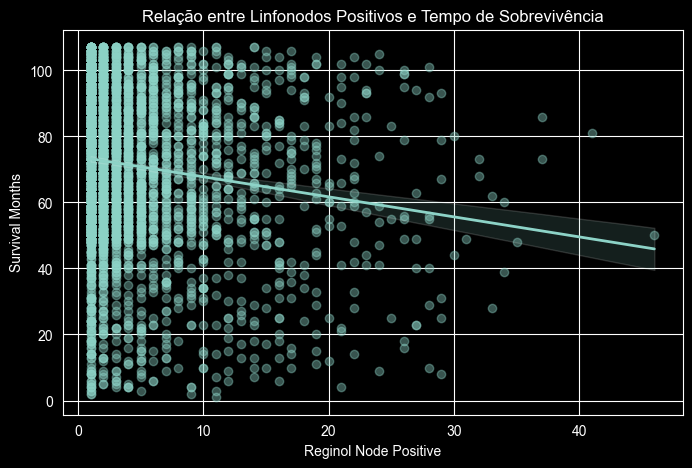

In [17]:
plt.figure(figsize=(8,5))

sns.regplot(
    x=df['Reginol Node Positive'],
    y=df['Survival Months'],
    scatter_kws={'alpha': 0.4},
    line_kws={'linewidth': 2}
)

plt.title("Relação entre Linfonodos Positivos e Tempo de Sobrevivência")
plt.xlabel("Reginol Node Positive")
plt.ylabel("Survival Months")
plt.savefig("../charts_images/positiveLinfonodos.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
corr = df[["Age",
    "Tumor Size",
    "Regional Node Examined",
    "Reginol Node Positive",
    "Survival Months"]].corr()

corr

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
Age,1.000000,-0.077215,-0.033345,0.012586,-0.009390
Tumor Size,-0.077215,1.000000,0.104352,0.242322,-0.086901
Regional Node Examined,-0.033345,0.104352,1.000000,0.411580,-0.022054
Reginol Node Positive,0.012586,0.242322,0.411580,1.000000,-0.135214
Survival Months,-0.009390,-0.086901,-0.022054,-0.135214,1.000000


Observou-se correlação positiva moderada entre Regional Node Examined e Reginol Node Positive (r = 0,41), indicando que pacientes com maior número de linfonodos examinados tendem a apresentar maior quantidade de linfonodos positivos.

A variável Tumor Size apresentou correlação positiva fraca com Reginol Node Positive (r = 0,24), sugerindo que tumores maiores podem estar associados a maior comprometimento nodal.

Foi observada correlação negativa fraca entre Reginol Node Positive e Survival Months (r = -0,14), indicando tendência de redução no tempo de sobrevivência conforme aumenta o comprometimento nodal

A idade não apresenta relação linear relevante com a sobrevivência nesse dataset, pois tumores maiores podem estar levemente associados à menor sobrevivencia

As variáveis relacionadas aos linfonodos possuem maior associação entre si e também apresentam relação com o tempo de sobrevivência.

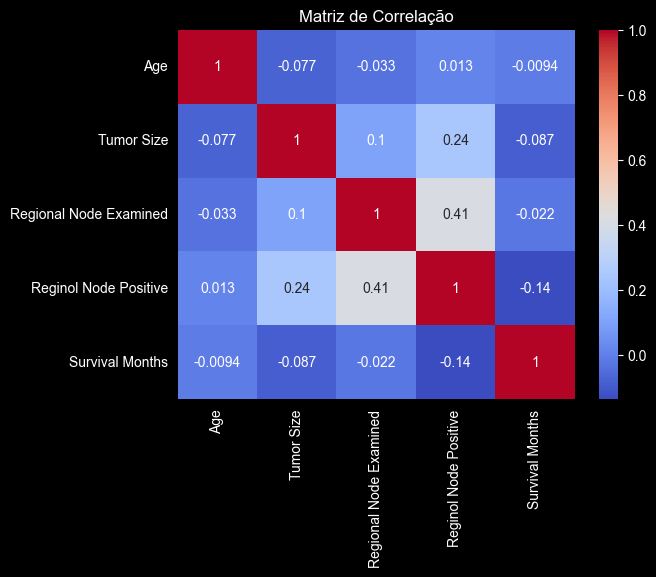

In [25]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de Correlação")
plt.savefig("../charts_images/correlationMatriz.png", dpi=300, bbox_inches="tight")
plt.show()

### 5 - Visualização das Variáveis Categóricas



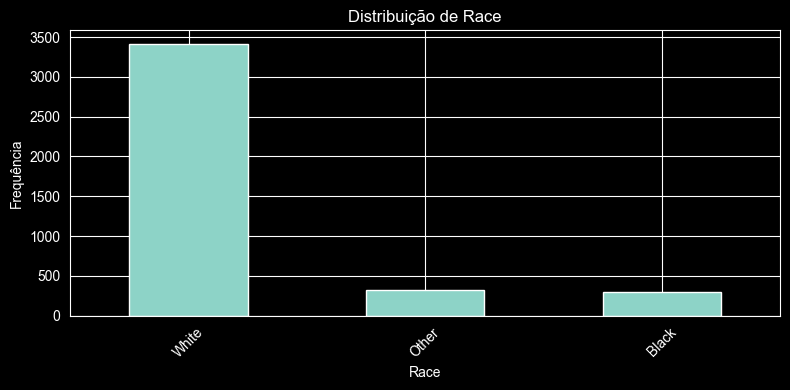

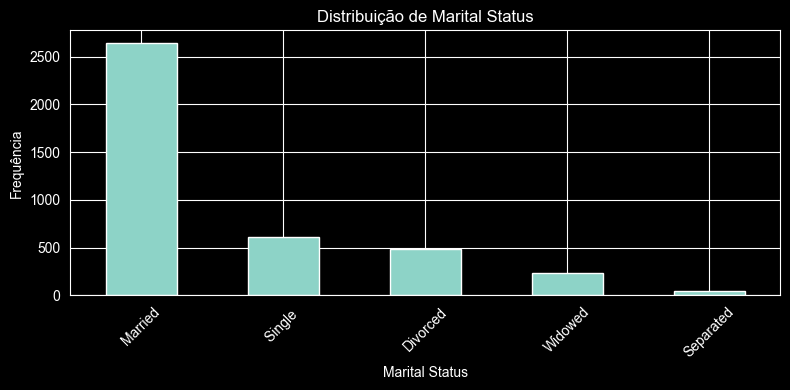

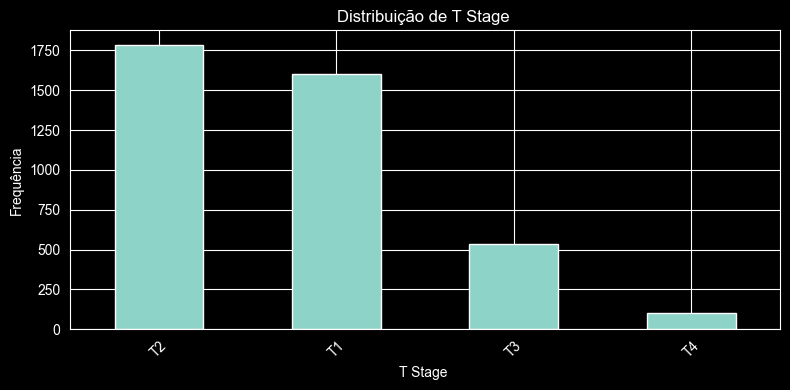

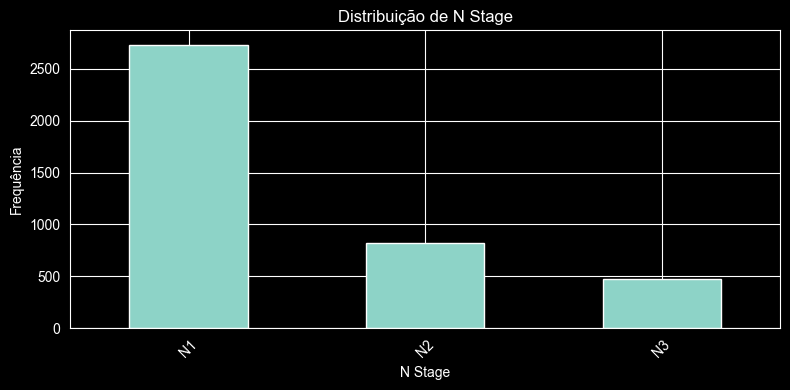

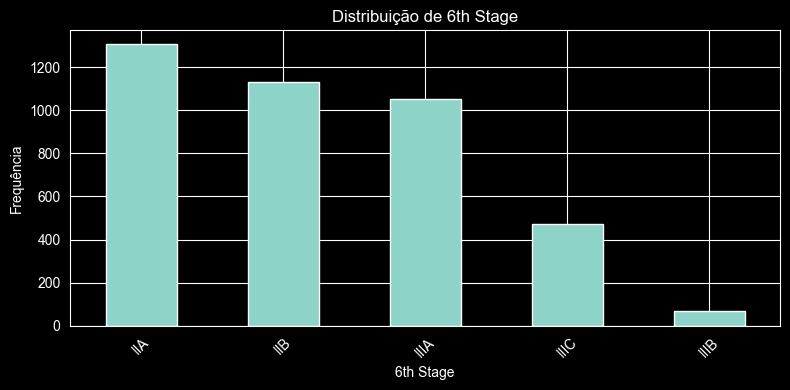

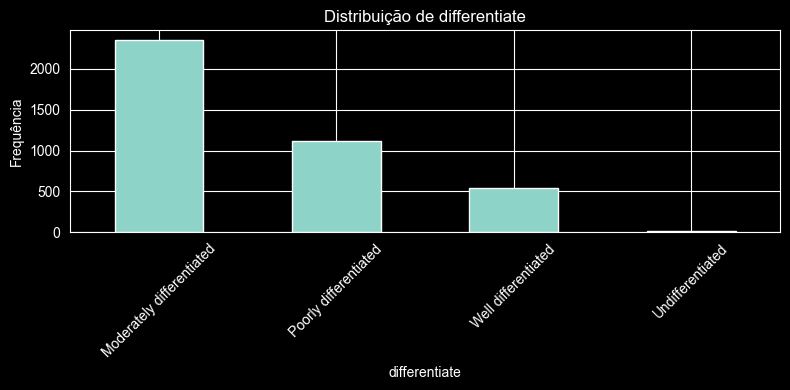

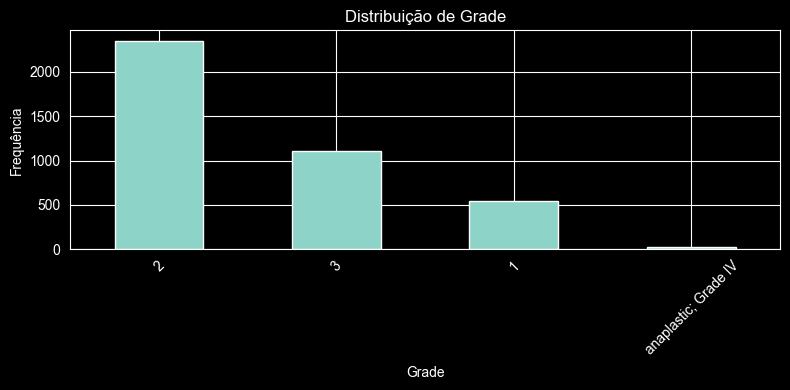

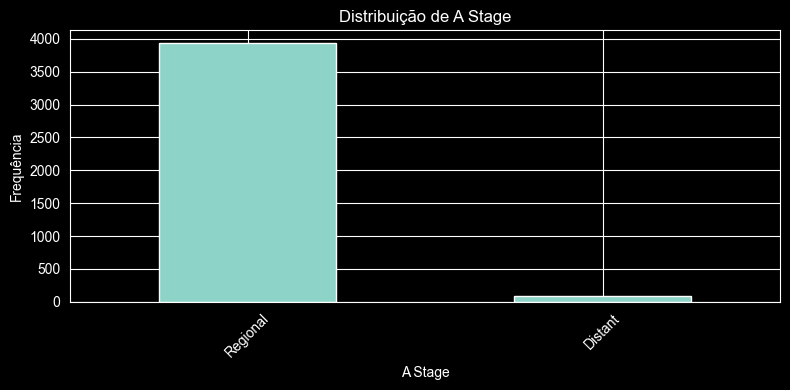

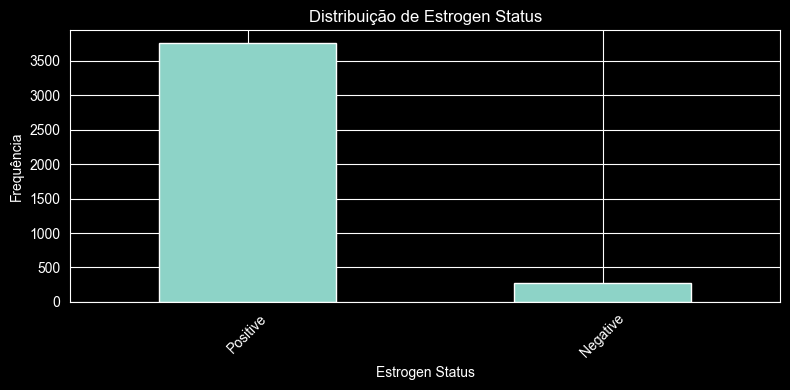

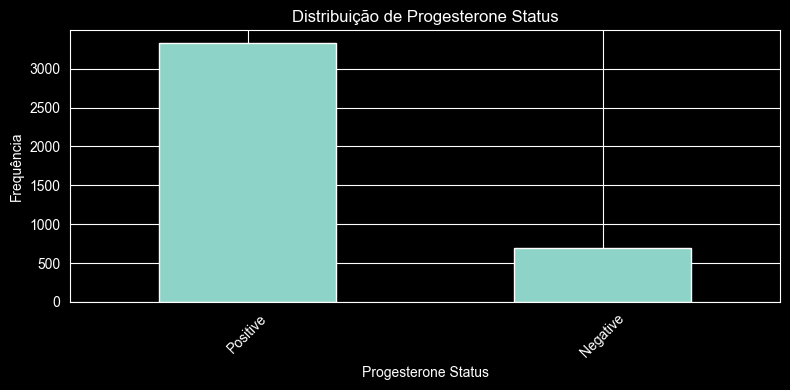

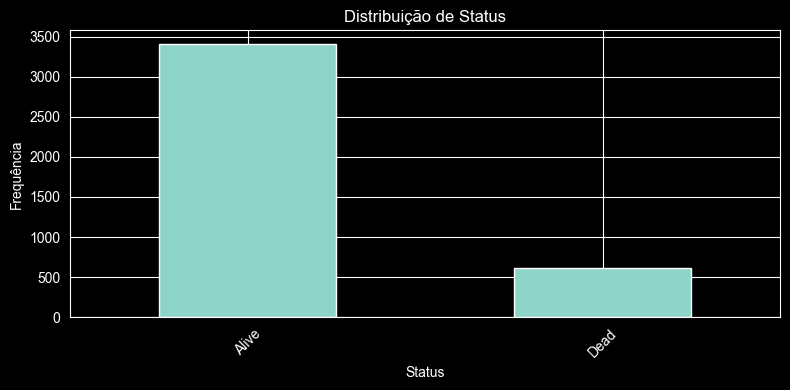

In [26]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45)
    plt.tight_layout()
    file_name = col.replace(" ", "_")
    plt.savefig(f"../charts_images/{file_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

### 6 - Distribuição das variaveis

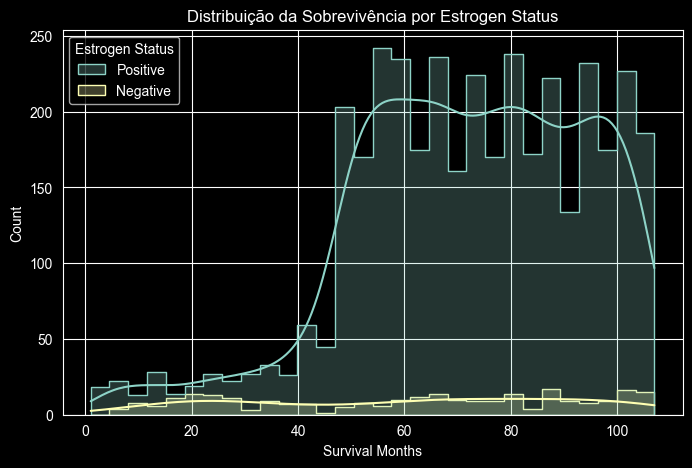

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Survival Months",
    hue="Estrogen Status",
    kde=True,
    bins=30,
    element="step"
)

plt.title("Distribuição da Sobrevivência por Estrogen Status")
plt.savefig("../charts_images/survivorEstrogenStatus.png", dpi=300, bbox_inches="tight")
plt.show()

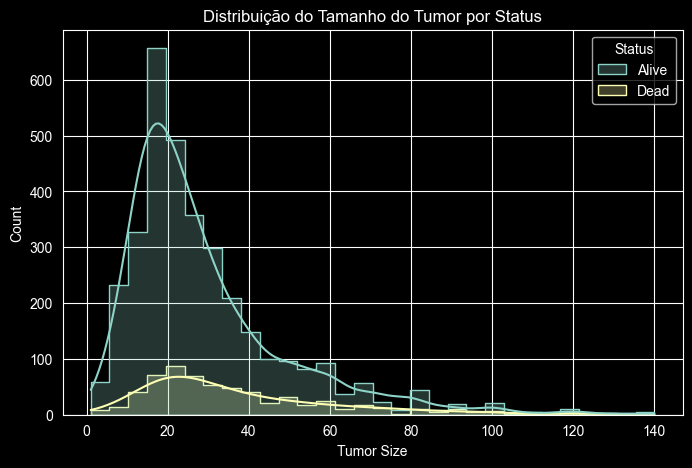

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tumor Size",
    hue="Status",
    kde=True,
    bins=30,
    element="step"
)

plt.title("Distribuição do Tamanho do Tumor por Status")
plt.savefig("../charts_images/correlationTumorSizeStatus.png", dpi=300, bbox_inches="tight")
plt.show()

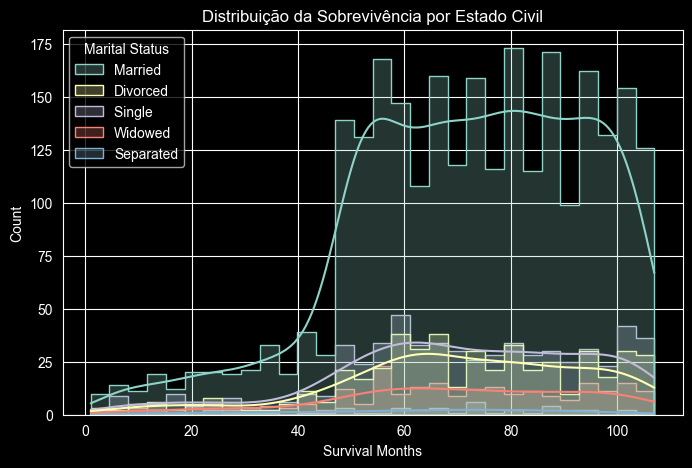

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Survival Months",
    hue="Marital Status",
    kde=True,
    bins=30,
    element="step"
)

plt.title("Distribuição da Sobrevivência por Estado Civil")
plt.savefig("../charts_images/averageMaritalStatusSurvival.png", dpi=300, bbox_inches="tight")
plt.show()

### 7 - Hipóteses

In [42]:
print("Pacientes positivos sobrevivem mais?")

positivo = df[df["Estrogen Status"] == "Positive"]["Survival Months"]
negativo = df[df["Estrogen Status"] == "Negative"]["Survival Months"]

hipotese1 = stats.ttest_ind(positivo, negativo)

media_positivo = positivo.mean()
media_negativo = negativo.mean()

print("p-valor:", hipotese1.pvalue)
print("Média Positive:", media_positivo)
print("Média Negative:", media_negativo)

if hipotese1.pvalue < 0.05:
    print("Existe diferença significativa entre os grupos")

    if media_positivo > media_negativo:
        print("Pacientes positivos sobrevivem mais, em média")
    else:
        print("Pacientes negativos sobrevivem mais, em média")
else:
    print("Não existe diferença significativa entre os grupos")

Pacientes positivos sobrevivem mais?
p-valor: 2.8191768683102073e-16
Média Positive: 72.08601864181092
Média Negative: 60.29739776951673
Existe diferença significativa entre os grupos
Pacientes positivos sobrevivem mais, em média


In [43]:
print("Pacientes que morreram tinham tumores maiores?")

alive = df[df["Status"] == "Alive"]["Tumor Size"]
dead = df[df["Status"] == "Dead"]["Tumor Size"]

hipotese2 = stats.ttest_ind(alive, dead)

media_alive = alive.mean()
media_dead = dead.mean()

print("p-valor:", hipotese2.pvalue)
print("Média Alive:", media_alive)
print("Média Dead:", media_dead)

if hipotese2.pvalue < 0.05:
    print("Existe diferença significativa")
    if media_dead > media_alive:
        print("Pacientes que morreram tinham tumores maiores")
    else:
        print("Pacientes vivos tinham tumores maiores")
else:
    print("Não existe diferença significativa")

Pacientes que morreram tinham tumores maiores?
p-valor: 1.2377493765575529e-17
Média Alive: 29.268779342723004
Média Dead: 37.13961038961039
Existe diferença significativa
Pacientes que morreram tinham tumores maiores


In [44]:
print("Pacientes que morreram tinham mais linfonodos positivos?")

alive = df[df["Status"] == "Alive"]["Reginol Node Positive"]
dead = df[df["Status"] == "Dead"]["Reginol Node Positive"]

hipotese3 = stats.ttest_ind(alive, dead)

media_alive = alive.mean()
media_dead = dead.mean()

print("p-valor:", hipotese3.pvalue)
print("Média Alive:", media_alive)
print("Média Dead:", media_dead)

if hipotese3.pvalue < 0.05:
    print("Existe diferença significativa")
    if media_dead > media_alive:
        print("Pacientes que morreram tinham mais linfonodos positivos")
    else:
        print("Pacientes vivos tinham mais linfonodos positivos")
else:
    print("Não existe diferença significativa")

Pacientes que morreram tinham mais linfonodos positivos?
p-valor: 1.5290313935284383e-61
Média Alive: 3.6006455399061035
Média Dead: 7.241883116883117
Existe diferença significativa
Pacientes que morreram tinham mais linfonodos positivos


In [45]:
print("Pacientes positivos possuem tumores menores?")

positivo = df[df["Estrogen Status"] == "Positive"]["Tumor Size"]
negativo = df[df["Estrogen Status"] == "Negative"]["Tumor Size"]

hipotese4 = stats.ttest_ind(positivo, negativo)

media_positivo = positivo.mean()
media_negativo = negativo.mean()

print("p-valor:", hipotese4.pvalue)
print("Média Positive:", media_positivo)
print("Média Negative:", media_negativo)

if hipotese4.pvalue < 0.05:
    print("Existe diferença significativa")
    if media_positivo < media_negativo:
        print("Pacientes positivos possuem tumores menores")
    else:
        print("Pacientes negativos possuem tumores menores")
else:
    print("Não existe diferença significativa")

Pacientes positivos possuem tumores menores?
p-valor: 0.00015561625114507565
Média Positive: 30.13688415446072
Média Negative: 35.174721189591075
Existe diferença significativa
Pacientes positivos possuem tumores menores


In [49]:
print("O estágio do tumor influencia a sobrevivência?")

t1 = df[df["T Stage "] == "T1"]["Survival Months"]
t2 = df[df["T Stage "] == "T2"]["Survival Months"]
t3 = df[df["T Stage "] == "T3"]["Survival Months"]
t4 = df[df["T Stage "] == "T4"]["Survival Months"]

hipotese5 = stats.f_oneway(t1, t2, t3, t4)

print("p-valor:", hipotese5.pvalue)
print("Média T1:", t1.mean())
print("Média T2:", t2.mean())
print("Média T3:", t3.mean())
print("Média T4:", t4.mean())

if hipotese5.pvalue < 0.05:
    print("Existe diferença significativa entre os estágios")
else:
    print("Não existe diferença significativa")

O estágio do tumor influencia a sobrevivência?
p-valor: 8.362503589348084e-07
Média T1: 73.56394260761073
Média T2: 70.30123180291153
Média T3: 68.88555347091932
Média T4: 65.74509803921569
Existe diferença significativa entre os estágios


In [52]:
print("Pacientes casados sobrevivem mais?")

casado = df[df["Marital Status"] == "Married"]["Survival Months"]
solteiro = df[df["Marital Status"] == "Single "]["Survival Months"]

hipotese6 = stats.ttest_ind(casado, solteiro)

media_casado = casado.mean()
media_solteiro = solteiro.mean()

print("p-valor:", hipotese6.pvalue)
print("Média casados:", media_casado)
print("Média solteiros:", media_solteiro)

if hipotese6.pvalue < 0.05:
    print("Existe diferença significativa")
    if media_casado > media_solteiro:
        print("Pacientes casados sobrevivem mais")
    else:
        print("Pacientes solteiros sobrevivem mais")
else:
    print("Não existe diferença significativa")

Pacientes casados sobrevivem mais?
p-valor: 0.12477266010236526
Média casados: 71.97956867196368
Média solteiros: 70.42276422764228
Não existe diferença significativa
